# Motorforsikring: innlasting, datarensing og kvalitetskontroll

Notebooken viser resultatene fra datakvalitetsmodulen. Variabelordbok,
rensing og integritetsdiagnostikk ligger i `src/data_quality.py`.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display
from sklearn.model_selection import GroupKFold

from src.coverage_visuals import (
    plot_coverage_by_policy_type_heatmap,
    plot_response_volume,
)
from src.data_quality import (
    build_integrity_diagnostics,
    build_variable_dictionary,
    clean_motor_data,
    find_variables,
    run_integrity_checks,
)
from src.portfolio_visuals import (
    plot_exposure_structure,
    plot_policy_type_composition,
)
from src.pre_split_diagnostics import (
    build_own_damage_scope_validation,
    build_pre_split_diagnostics,
)
from src.train_test_split import build_key_variable_balance, build_split_summary

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
DATA_PATH = Path("data/Dataset of motor insurance portfolio.csv")
DESCRIPTION_PATH = Path("data/Descriptive of variables.xlsx")
if not DATA_PATH.exists() or not DESCRIPTION_PATH.exists():
    raise FileNotFoundError(
        "Kjør notebooken fra prosjektroten slik at begge filene i data/ er tilgjengelige."
    )

seed = 100

## 1. Uendret innlasting og første inspeksjon

CSV-en leses før rensing. Excel-filen brukes som kildekontroll, mens den
forbedrede variabelordboken bygges i scriptet.

In [2]:
raw_data = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8", low_memory=False)
source_dictionary_raw = pd.read_excel(
    DESCRIPTION_PATH,
    sheet_name="Cartera",
    usecols=["Variables", "Description", "Group"],
)
source_variables = source_dictionary_raw["Variables"].dropna().astype(str).tolist()
variable_dictionary = build_variable_dictionary()
raw_overview = pd.Series(
    {
        "Antall rader": len(raw_data),
        "Antall kolonner": raw_data.shape[1],
        "Unike insured_id": raw_data["insured_id"].nunique(),
        "Duplikate hele rader": int(raw_data.duplicated().sum()),
        "Duplikate (insured_id, year)": int(
            raw_data.duplicated(["insured_id", "year"]).sum()
        ),
        "Minste år": int(raw_data["year"].min()),
        "Største år": int(raw_data["year"].max()),
        "Variabler dokumentert i Excel": len(source_variables),
        "Excel- og CSV-variabler er identiske": source_variables
        == raw_data.columns.tolist(),
        "Minnestørrelse (MiB)": round(
            raw_data.memory_usage(deep=True).sum() / 1024**2, 1
        ),
    },
    name="Verdi",
).to_frame()
display(raw_overview)
display(raw_data.head())

,Verdi
Antall rader,354140
Antall kolonner,47
Unike insured_id,185678
Duplikate hele rader,0
"Duplikate (insured_id, year)",0
Minste år,2022
Største år,2024
Variabler dokumentert i Excel,47
Excel- og CSV-variabler er identiske,True
Minnestørrelse (MiB),257.4


,insured_id,year,policy_type,policy_status,business_type,payment_frequency,bonus_score,driver_age,vehicle_age,age_driving_licence,fuel_type,vehicle_value,seats,power_to_weight_ratio,vehicle_brand,municipality_type,circulation_area,total_premium,liability_premium,property_damage_premium,theft_premium,fire_premium,glass_premium,legal_protection_premium,occupants_premium,total_claims,liability_claims,liability_property_claims,liability_injury_claims,property_claims,theft_claims,fire_claims,glass_claims,legal_protection_claims,occupants_claims,total_incurred,liability_incurred,liability_property_incurred,liability_injury_incurred,property_incurred,theft_incurred,fire_incurred,glass_incurred,legal_protection_incurred,occupants_incurred,total_exposure,liability_exposure
0,1,2022,COMP_E,C,NB,A,G,48,22.0,26.0,G,149511.4425,4,3.92,PORSCHE,I,U,279.557558,30.602324,121.912690,112.361489,3.832441,8.305788,2.043622,0.499205,0,0,0,0,0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.09863,0.09863
1,2,2022,COMP_E,A,P,A,G,43,24.0,19.0,D,65065.1232,8,10.15,MERCEDES,I,U,546.623415,114.333356,303.105967,80.784824,7.826861,30.091751,7.812747,2.667908,0,0,0,0,0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000
2,2,2023,COMP_E,A,P,A,G,44,25.0,19.0,D,65065.1232,8,10.15,MERCEDES,I,U,548.752558,110.666891,304.955990,83.521384,6.151465,32.861626,7.655637,2.939566,1,1,1,0,0,0,0,0,0,0,233.0130,233.013,233.013,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000
3,2,2024,COMP_E,A,P,A,G,45,26.0,18.0,D,65065.1232,8,10.15,MERCEDES,I,U,584.632430,122.092532,305.225093,107.886872,5.842892,31.101584,10.084173,2.399283,2,1,1,0,1,0,0,0,0,0,2586.3615,1035.000,1035.000,0.0,1551.3615,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000
4,3,2022,COMP_E,A,NB,S,G,45,26.0,19.0,D,51626.6625,7,9.19,KIA,I,R,687.490508,214.583989,354.874140,53.077620,7.715765,48.574298,6.700701,1.963995,0,0,0,0,0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000


In [3]:
raw_schema = pd.DataFrame(
    {
        "raw_dtype": raw_data.dtypes.astype(str),
        "missing_count": raw_data.isna().sum(),
        "missing_percent": raw_data.isna().mean().mul(100).round(4),
        "unique_count": raw_data.nunique(dropna=False),
        "example": [
            raw_data[column].dropna().iloc[0]
            if raw_data[column].notna().any()
            else pd.NA
            for column in raw_data.columns
        ],
    }
)
display(raw_schema)
display(
    raw_data.isna()
    .groupby(raw_data["year"])
    .sum()
    .loc[:, lambda frame: frame.sum().gt(0)]
    .T
)

,raw_dtype,missing_count,missing_percent,unique_count,example
insured_id,int64,0,0.0000,185678,1
year,int64,0,0.0000,3,2022
policy_type,str,0,0.0000,5,COMP_E
policy_status,str,0,0.0000,2,C
business_type,str,0,0.0000,2,NB
payment_frequency,str,0,0.0000,3,A
bonus_score,str,0,0.0000,3,G
driver_age,int64,0,0.0000,73,48
vehicle_age,float64,2,0.0006,69,22.0
age_driving_licence,float64,2,0.0006,72,26.0


year,2022,2023,2024
vehicle_age,0,1,1
age_driving_licence,0,1,1
fuel_type,171,397,719
vehicle_value,111,173,229


## 2. Variabelordbok

`variable_dictionary` er en dataframe bygget i scriptet og kan filtreres
senere med `find_variables(variable_dictionary, ...)`.

In [4]:
display(find_variables(variable_dictionary, search="policy_type"))

,variable,group,description,unit_or_codes,analysis_role,clean_dtype,missing_allowed
0,policy_type,Polise og kontrakt,Overordnet produkt-/dekningsstruktur for polisen.,TP=ansvar; TPG=ansvar+glass; CC=ansvar+minst to tilleggsdekninger; COMP_E=kasko med egenandel; COMP_N=kasko uten ege...,Kategorisk risikofaktor,category,Nei


In [5]:
raw_data[raw_data["power_to_weight_ratio"] <= 0].head()

,insured_id,year,policy_type,policy_status,business_type,payment_frequency,bonus_score,driver_age,vehicle_age,age_driving_licence,fuel_type,vehicle_value,seats,power_to_weight_ratio,vehicle_brand,municipality_type,circulation_area,total_premium,liability_premium,property_damage_premium,theft_premium,fire_premium,glass_premium,legal_protection_premium,occupants_premium,total_claims,liability_claims,liability_property_claims,liability_injury_claims,property_claims,theft_claims,fire_claims,glass_claims,legal_protection_claims,occupants_claims,total_incurred,liability_incurred,liability_property_incurred,liability_injury_incurred,property_incurred,theft_incurred,fire_incurred,glass_incurred,legal_protection_incurred,occupants_incurred,total_exposure,liability_exposure
350755,182681,2023,TPG,A,NB,A,G,39,16.0,23.0,D,27469.163925,3,0.0,IVECO,I,R,112.830837,90.701099,0.000000,0.000000,0.000000,19.966862,1.743789,0.419087,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.394521,0.394521
350756,182681,2024,TPG,A,P,A,G,40,16.0,23.0,D,27469.163925,3,0.0,IVECO,I,R,291.139488,231.140084,0.000000,0.000000,0.000000,54.117296,4.718680,1.163429,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000
353855,185394,2024,COMP_E,A,NB,A,G,51,33.0,18.0,D,26273.751000,3,0.0,IVECO,C,U,75.060590,25.086733,39.690763,3.599475,0.271363,5.209388,0.926287,0.276582,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.106849,0.106849


## 3. Beslutninger etter datakontroll

Følgende beslutninger gjelder dette datasettet:

- `power_to_weight_ratio <= 0` settes til manglende. Tre rader omfattes.
- `age_driving_licence` tolkes som antall år poliseholderen har hatt førerkort.
  Verdier under 18 er derfor ikke et datakvalitetsavvik.
- En kansellert polise med full eksponering beholdes uendret.
- Skader med null `incurred` beholdes som nullskader.
- Polise `(insured_id=23744, year=2022)` har en ansvarsskade, men null
  eksponering. Både `total_exposure` og `liability_exposure` settes til 1, slik
  at de fortsatt er konsistente.
- Positiv ansvarseksponering med null ansvarspremie beholdes. Kontrollen fant 23
  slike rader for 17 poliser; én av polisene har positiv ansvarspremie i senere
  år. Nullpremien behandles derfor som et premieavvik, ikke som null risiko.
  Radene skal flagges ved senere premieanalyse, men eksponeringen brukes i
  skademodeller.

## 4. Rensing

Rensingen låser skjema og datatyper, standardiserer kategorier og utfører de
dokumenterte korreksjonene over. Ingen rader slettes eller imputeres.

In [6]:
data, cleaning_log = clean_motor_data(raw_data, variable_dictionary)
display(cleaning_log)
display(
    pd.DataFrame(
        {
            "raw_dtype": raw_data.dtypes.astype(str),
            "clean_dtype": data.dtypes.astype(str),
            "missing_after_cleaning": data.isna().sum(),
        }
    )
    .sort_values("missing_after_cleaning", ascending=False)
    .head(6)
)

,step,affected_rows,result
0,"Kontroll av skjema, kategorikoder og unik poliseår-nøkkel",0,Bestått
1,Fjerning av omkringliggende mellomrom i tekstfelt,0,Standardisert
2,Ikke-positiv power_to_weight_ratio satt til manglende,3,Standardisert
3,Manglende total- og ansvarseksponering satt til 1 for ansvarsskade,1,Korrigert
4,Rader slettet eller imputert,0,Ingen


,raw_dtype,clean_dtype,missing_after_cleaning
fuel_type,str,category,1287
vehicle_value,float64,float64,513
power_to_weight_ratio,float64,float64,3
vehicle_age,float64,Int16,2
age_driving_licence,float64,Int16,2
year,int64,Int16,0


In [7]:
display(
    data.loc[
        data["power_to_weight_ratio"].isna(),
        ["insured_id", "year", "power_to_weight_ratio"],
    ]
)

,insured_id,year,power_to_weight_ratio
350755,182681,2023,NaN
350756,182681,2024,NaN
353855,185394,2024,NaN


## 5. Integritetsdiagnostikk

Alle kontroller kjøres i scriptet. Notebooken presenterer oppsummeringene og
beholder dem som dataframes/datastrukturer for senere oppslag.

In [8]:
integrity_checks = run_integrity_checks(data, variable_dictionary)
diagnostics = build_integrity_diagnostics(data, integrity_checks)
critical_failures = diagnostics["critical_failures"]
warning_examples = diagnostics["warning_examples"]
coverage_diagnostics = diagnostics["coverage_diagnostics"]
temporal_diagnostics = diagnostics["temporal_diagnostics"]
display(integrity_checks)
display(warning_examples)
display(coverage_diagnostics)
display(temporal_diagnostics)
if not critical_failures.empty:
    raise AssertionError(
        "Minst én kritisk integritetskontroll feilet. Se critical_failures."
    )

,check,severity,expectation,violating_rows,status
0,"Unik (insured_id, year)",Kritisk,Ingen duplikate poliseår,0,Bestått
1,Manglende i obligatoriske felt,Kritisk,Ingen manglende verdier,0,Bestått
2,Endelige numeriske verdier,Kritisk,Ingen +inf eller -inf,0,Bestått
3,Ikke-negative premier,Kritisk,Alle premier >= 0,0,Bestått
4,Ikke-negative skadeantall,Kritisk,Alle skadeantall >= 0,0,Bestått
5,Ikke-negative incurred-beløp,Kritisk,Alle incurred-beløp >= 0,0,Bestått
6,Eksponering innenfor gyldig område,Kritisk,"Begge eksponeringer i [0, 1]",0,Bestått
7,Totalpremie summerer,Kritisk,total_premium = sum dekningspremier,0,Bestått
8,Totalt skadeantall summerer,Kritisk,total_claims = sum skadeantall per dekning,0,Bestått
9,Ansvarsskadeantall summerer,Kritisk,liability_claims = property + injury under ansvar,0,Bestått


,check,insured_id,year,policy_type,policy_status,business_type,age_driving_licence,liability_premium,total_premium,total_claims,total_incurred,total_exposure
0,Positiv ansvarseksponering med null ansvarspremie,50075,2022,CC,A,NB,20,0.0,44.522410,0,0.0,0.539726
1,Positiv ansvarseksponering med null ansvarspremie,73579,2023,COMP_E,A,NB,20,0.0,107.349196,0,0.0,0.369863
2,Positiv ansvarseksponering med null ansvarspremie,73579,2024,COMP_E,A,NB,19,0.0,294.780318,0,0.0,1.000000
3,Positiv ansvarseksponering med null ansvarspremie,78590,2023,COMP_E,A,NB,19,0.0,269.079700,0,0.0,0.813699
4,Positiv ansvarseksponering med null ansvarspremie,78590,2024,COMP_E,A,NB,19,0.0,326.888858,0,0.0,1.000000


,coverage,zero_premium_rows,claim_with_zero_premium,incurred_with_zero_premium
0,Ansvar,72,1,1
1,Egen skade,244802,2,2
2,Tyveri,42180,0,0
3,Brann,42183,0,0
4,Glass,5839,0,0
5,Rettshjelp,67,0,0
6,Passasjer,69,0,0


,variable,comparable_transitions,unchanged,decrease,increase_larger_than_year_gap
0,driver_age,168462,54527,42,14
1,vehicle_age,168461,54494,113,77
2,age_driving_licence,168461,147969,19571,57


## 6. Renseutfall og avgrensning for neste fase

Det rensede analysegrunnlaget ligger i `data`. Ingen rader er slettet og ingen
verdier er imputert. Diagnosene er funn som må vurderes før modellering.

# Deskriptiv analyse

Før train/test-splitt gjør vi bare strukturell porteføljediagnostikk. Tabellene
under brukes til å definere risikopopulasjoner og vurdere tidsstrukturen, ikke
til å velge prediktorer eller transformasjoner fra skadeutfall.

## 7. Porteføljestørrelse, eksponering og panelstruktur

Eksponeringsstatus per år (null / delår / full år) viser porteføljens vekst
og at andelen fullårseksponerte poliser øker mot 2024. Panelstrukturen —
hvor lenge poliser observeres — begrunner en tidsbasert train/test-splitt
fremfor en tilfeldig radsplitt: samme polise opptrer typisk i flere år.

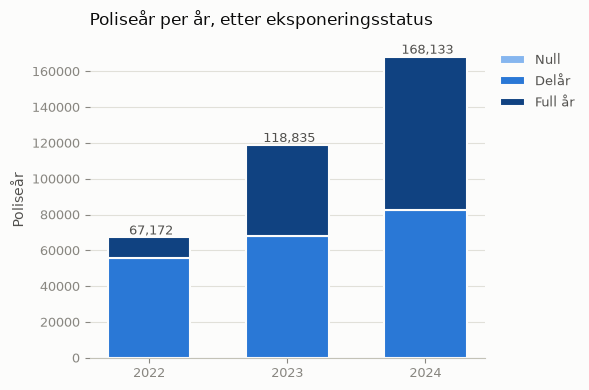

In [9]:
pre_split = build_pre_split_diagnostics(data)
display(plot_exposure_structure(data))

In [10]:
display(pre_split["panel_duration"])

,observerte_år,antall_poliser
0,1,67743
1,2,67408
2,3,50527


48 poliser har null eksponering og null premie i 2024 (aktive i 2022/2023,
men ikke fornyet). De beholdes i datasettet for sporbarhet, men utelates fra
skadeanalysen og train/test-splitten siden de ikke representerer risiko i
noen periode med positiv eksponering.

In [11]:
assert pre_split["exposure_checks"]["antall_poliseår"].eq(0).all(), (
    "Uventet avvik i eksponeringskontrollen — se build_exposure_summary."
)

## 8. Porteføljesammensetning: policy_type

`policy_type` er den sentrale klassifiseringsvariabelen for dekning (se
dekningsmatrisen under) og er stabil over tid. Øvrige
sammensetningsvariabler er ikke kritiske for avgrensningsbeslutningen;
`vehicle_brand` har særlig mange nivåer og egner seg bedre som prediktor
senere i analysen enn som deskriptiv oversikt her.

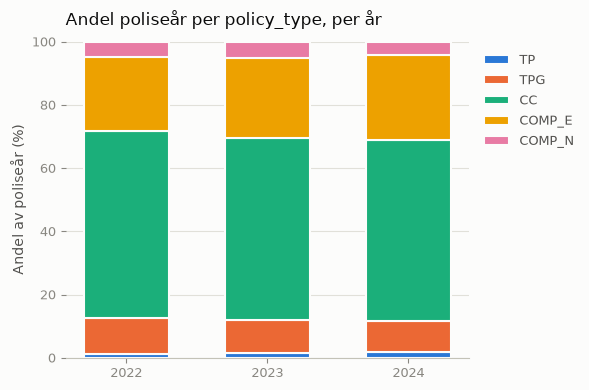

In [12]:
display(plot_policy_type_composition(data))

## 9. Dekningsmatrise

Ansvar anses aktivt når `liability_exposure > 0`. For andre dekninger brukes
positiv totaleksponering og positiv dekningspremie som en praktisk proxy for
at dekningen er aktiv (ingen per-dekning eksponeringsvariabel finnes).
Matrisen viser at egen skade (kasko) kun er aktiv for `policy_type` CC,
COMP_E og COMP_N — konsistent med at TP/TPG er rene ansvarsprodukter.

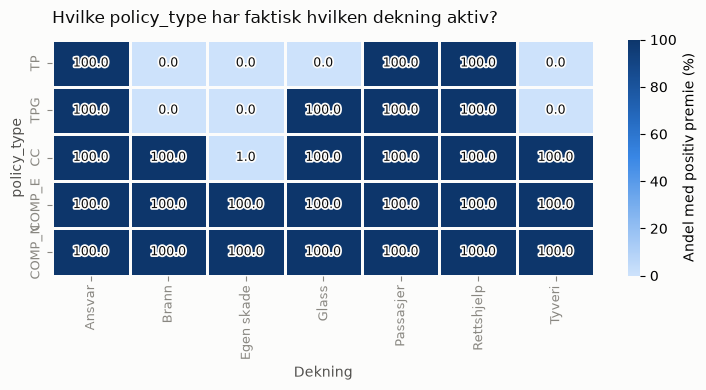

In [13]:
display(plot_coverage_by_policy_type_heatmap(pre_split["coverage_by_policy_type"]))

In [14]:
display(pre_split["coverage_summary"])

,dekning,regel_for_aktiv_dekning,poliseår_i_risiko,samlet_eksponering,andel_av_porteføljen_prosent,poliseår_med_positiv_premie,skade_med_null_premie,incurred_med_null_premie
0,Ansvar,liability_exposure > 0,354092,250326.90,99.99,354068,1,1
1,Egen skade,total_exposure > 0 og dekningspremie > 0,109338,79243.05,30.87,109338,2,2
2,Tyveri,total_exposure > 0 og dekningspremie > 0,311960,221610.80,88.09,311960,0,0
3,Brann,total_exposure > 0 og dekningspremie > 0,311957,221608.29,88.09,311957,0,0
4,Glass,total_exposure > 0 og dekningspremie > 0,348301,246501.91,98.35,348301,0,0
5,Rettshjelp,total_exposure > 0 og dekningspremie > 0,354073,250315.30,99.98,354073,0,0
6,Passasjer,total_exposure > 0 og dekningspremie > 0,354071,250313.29,99.98,354071,0,0


## 10. Responsvolum og eksponering per dekning

Ren volumkontroll per dekning, ikke analyse av skadeutfall mot
risikofaktorer. Egen skade har det klart høyeste skadevolumet blant
kasko-relevante dekninger, men klart lavest eksponering — fordi
risikopopulasjonen for egen skade er avgrenset til poliser med positiv
`property_damage_premium` (se `_coverage_mask`), mens de øvrige dekningene
dekker nær hele porteføljen.

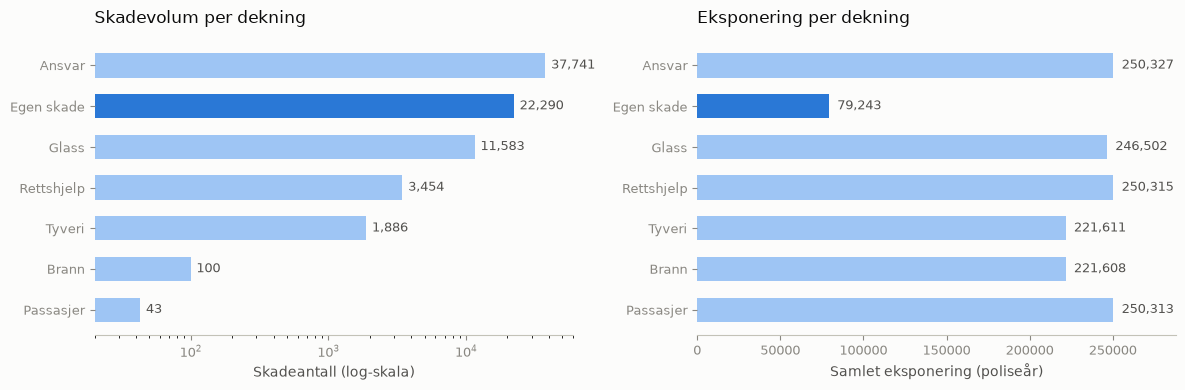

In [15]:
display(plot_response_volume(pre_split["response_summary"]))

In [16]:
display(pre_split["response_summary"])

,dekning,poliseår_i_risiko,samlet_eksponering,skadeantall,poliseår_med_skade,poliseår_med_flere_skader,samlet_incurred,skaderader_med_null_incurred,modellomfang
0,Ansvar,354092,250326.90,37741,30707,6004,47350877.23,9971,Selvstendig modellering aktuell
1,Egen skade,109338,79243.05,22290,12535,4194,18646804.98,11,Selvstendig modellering aktuell
2,Tyveri,311960,221610.80,1886,1845,41,1597689.70,0,Enklere modell eller sammenslåing
3,Brann,311957,221608.29,100,100,0,270157.59,1,For lite for selvstendig detaljmodell
4,Glass,348301,246501.91,11583,11152,413,4460227.80,2,Selvstendig modellering aktuell
5,Rettshjelp,354073,250315.30,3454,3395,59,1176874.22,51,Enklere modell eller sammenslåing
6,Passasjer,354071,250313.29,43,43,0,358890.65,0,For lite for selvstendig detaljmodell


## 11. Avgrensning til egen-skadedekning

Basert på dekningsmatrisen (seksjon 9) og responsvolumet (seksjon 10)
avgrenses videre analyse til poliseår med positiv `property_damage_premium`
og positiv `total_exposure`. Premien brukes bare til å identifisere at
dekningen er aktiv, ikke som prediktor. Denne avgrensningen gir en tydelig
risikopopulasjon med tilstrekkelig skadevolum for både frekvens- og
severitymodellering. Naturlige utvidelser er å gjenta samme analyse separat
for de øvrige dekningene.

In [17]:
own_damage_mask = data["property_damage_premium"].gt(0) & data["total_exposure"].gt(0)
df = data.loc[own_damage_mask].copy()
scope_summary, scope_exceptions = build_own_damage_scope_validation(df)
display(scope_summary)
display(scope_exceptions)
assert df["property_damage_premium"].gt(0).all()
assert df["total_exposure"].gt(0).all()

,policy_type,poliseår,poliseår_med_positiv_eksponering,poliseår_i_modell,skadeantall_i_modell,andel_av_positive_eksponeringer_prosent
0,CC,1978,1978,1978,309,100.0
1,COMP_E,91181,91181,91181,12102,100.0
2,COMP_N,16179,16179,16179,9879,100.0


,insured_id,year,policy_type,policy_status,total_exposure,property_damage_premium,property_claims,property_incurred


Valideringen viser hvordan avgrensningen fordeler seg på produkttype og lister
alle skader som faller utenfor regelen. Slike unntak beholdes som dokumenterte
datavvik, men brukes ikke til å definere dekning fordi det ville innebære at
skadeutfallet bestemmer modellpopulasjonen.

In [18]:
df.loc[(df["total_exposure"]) != (df["liability_exposure"])]

,insured_id,year,policy_type,policy_status,business_type,payment_frequency,bonus_score,driver_age,vehicle_age,age_driving_licence,fuel_type,vehicle_value,seats,power_to_weight_ratio,vehicle_brand,municipality_type,circulation_area,total_premium,liability_premium,property_damage_premium,theft_premium,fire_premium,glass_premium,legal_protection_premium,occupants_premium,total_claims,liability_claims,liability_property_claims,liability_injury_claims,property_claims,theft_claims,fire_claims,glass_claims,legal_protection_claims,occupants_claims,total_incurred,liability_incurred,liability_property_incurred,liability_injury_incurred,property_incurred,theft_incurred,fire_incurred,glass_incurred,legal_protection_incurred,occupants_incurred,total_exposure,liability_exposure


In [19]:
df.head()

,insured_id,year,policy_type,policy_status,business_type,payment_frequency,bonus_score,driver_age,vehicle_age,age_driving_licence,fuel_type,vehicle_value,seats,power_to_weight_ratio,vehicle_brand,municipality_type,circulation_area,total_premium,liability_premium,property_damage_premium,theft_premium,fire_premium,glass_premium,legal_protection_premium,occupants_premium,total_claims,liability_claims,liability_property_claims,liability_injury_claims,property_claims,theft_claims,fire_claims,glass_claims,legal_protection_claims,occupants_claims,total_incurred,liability_incurred,liability_property_incurred,liability_injury_incurred,property_incurred,theft_incurred,fire_incurred,glass_incurred,legal_protection_incurred,occupants_incurred,total_exposure,liability_exposure
0,1,2022,COMP_E,C,NB,A,G,48,22,26,G,149511.4425,4,3.92,PORSCHE,I,U,279.557558,30.602324,121.912690,112.361489,3.832441,8.305788,2.043622,0.499205,0,0,0,0,0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.09863,0.09863
1,2,2022,COMP_E,A,P,A,G,43,24,19,D,65065.1232,8,10.15,MERCEDES,I,U,546.623415,114.333356,303.105967,80.784824,7.826861,30.091751,7.812747,2.667908,0,0,0,0,0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000
2,2,2023,COMP_E,A,P,A,G,44,25,19,D,65065.1232,8,10.15,MERCEDES,I,U,548.752558,110.666891,304.955990,83.521384,6.151465,32.861626,7.655637,2.939566,1,1,1,0,0,0,0,0,0,0,233.0130,233.013,233.013,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000
3,2,2024,COMP_E,A,P,A,G,45,26,18,D,65065.1232,8,10.15,MERCEDES,I,U,584.632430,122.092532,305.225093,107.886872,5.842892,31.101584,10.084173,2.399283,2,1,1,0,1,0,0,0,0,0,2586.3615,1035.000,1035.000,0.0,1551.3615,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000
4,3,2022,COMP_E,A,NB,S,G,45,26,19,D,51626.6625,7,9.19,KIA,I,R,687.490508,214.583989,354.874140,53.077620,7.715765,48.574298,6.700701,1.963995,0,0,0,0,0,0,0,0,0,0,0.0000,0.000,0.000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,1.00000,1.00000


## 12. Train/test-splitt

Splitten er tidsbasert (out-of-time), ikke en tilfeldig radsplitt: 2022 og
2023 slås sammen til en train/CV-pool, mens 2024 holdes urørt som endelig
test. Dette speiler faktisk bruk av en prisingsmodell — fit på historikk,
prises på neste års fornyelser — og fanger opp temporal drift (f.eks.
skadeinflasjon) som en tilfeldig splitt ikke ville avslørt.

Hyperparametertuning skjer med `GroupKFold` på `insured_id` innad i
train/CV-pool, ikke vanlig radbasert k-fold: samme polise kan opptre i både
2022 og 2023, og uten gruppering kunne de to poliseårene til samme polise
havnet i ulike foldere og gitt et for optimistisk CV-estimat. Testsettet
rører vi ikke igjen før endelig evaluering. All videre deskriptiv/
eksplorativ analyse av prediktorer bør fra nå av kun bruke `train_pool`.

In [20]:
TRAIN_YEARS = [2022, 2023]
TEST_YEAR = 2024


def make_train_test_split(frame, n_splits=5):
    """Del modellpopulasjonen i en train/CV-pool og en urørt testperiode."""
    train_pool = frame.loc[frame["year"].isin(TRAIN_YEARS)].copy()
    test = frame.loc[frame["year"].eq(TEST_YEAR)].copy()
    cv = GroupKFold(n_splits=n_splits)
    return train_pool, test, cv


def check_group_disjoint_folds(train_pool, cv, groups):
    """Bekreft at ingen insured_id opptrer i både train- og valideringsfold."""
    for fold, (train_idx, val_idx) in enumerate(cv.split(train_pool, groups=groups)):
        train_fold_ids = set(groups.iloc[train_idx])
        val_fold_ids = set(groups.iloc[val_idx])
        if train_fold_ids & val_fold_ids:
            raise ValueError(
                f"Fold {fold} har overlappende insured_id mellom train og val."
            )
    return True

In [21]:
train_pool, test, cv = make_train_test_split(df, n_splits=5)
split_summary, overlap_summary = build_split_summary(train_pool, test)
display(split_summary)
display(overlap_summary)

,sett,poliseår,unike_poliser,eksponering,skadeantall,andel_poliseår_med_skade_prosent,incurred
0,Train/CV-pool (2022-2023),56084,37727,37904.44,10126,10.30,8803785.41
1,Test (2024),53254,53254,41338.61,12164,12.69,9843019.58


,Verdi
unike_poliser_train_pool,37727.00
unike_poliser_test,53254.00
poliser_i_begge,33503.00
andel_av_test_som_er_videreført_prosent,62.91


Overlappen mellom train/CV-pool og test er forventet og ønsket her — det
er videreførte poliser som prises på nytt i 2024, ikke lekkasje. Til slutt
bekreftes det at `GroupKFold` faktisk holder `insured_id` adskilt mellom
train- og valideringsfold.

In [22]:
check_group_disjoint_folds(train_pool, cv, train_pool["insured_id"])

True

### Balansediagnostikk: nøkkelvariabler i train/CV-pool vs. test

Splitten er tidsbasert, ikke tilfeldig, så det er ikke gitt at fordelingen av
sentrale risikofaktorer er lik i de to periodene. Tabellene under viser andel
per kategori (kategoriske variabler) og standardized mean difference, SMD
(numeriske variabler) mellom train/CV-pool og test. Store avvik er ikke i seg
selv et problem — testsettet skal representere fremtidige fornyelser, ikke en
tilfeldig delmengde av samme populasjon — men avvik bør være kjent før
modellresultater tolkes.

In [23]:
categorical_balance, numeric_balance = build_key_variable_balance(train_pool, test)
display(categorical_balance)
display(numeric_balance)

,variabel,kategori,train_prosent,test_prosent,diff_prosentpoeng,betydelig_avvik
0,policy_type,CC,1.49,2.14,-0.65,False
1,policy_type,COMP_E,81.90,84.96,-3.06,False
2,policy_type,COMP_N,16.60,12.89,3.71,False
3,policy_type,TP,0.00,0.00,0.00,False
4,policy_type,TPG,0.00,0.00,0.00,False
5,bonus_score,B,1.71,0.97,0.74,False
6,bonus_score,G,96.10,97.00,-0.90,False
7,bonus_score,N,2.19,2.04,0.16,False
8,fuel_type,D,73.98,73.44,0.55,False
9,fuel_type,G,26.02,26.56,-0.55,False


,variabel,train_snitt,test_snitt,train_std,test_std,smd,betydelig_avvik
0,driver_age,47.60,48.94,11.67,11.72,-0.114,True
1,age_driving_licence,22.22,22.24,5.63,5.68,-0.002,False
2,vehicle_age,25.31,26.58,11.13,11.23,-0.114,True
3,vehicle_value,32453.81,32244.99,13644.51,13532.27,0.015,False
4,power_to_weight_ratio,11.48,11.51,2.08,2.04,-0.018,False


In [24]:
cv

GroupKFold(n_splits=5, random_state=None, shuffle=False)